# Cuestionario Práctico de Computación Cuántica con Qiskit

A continuación, resuelve los siguientes ejercicios escribiendo el código correspondiente en Qiskit para demostrar tu respuesta. Puedes utilizar las funciones de visualización provistas en clase (como `analizar_circuito`, `Statevector`, `plot_bloch_multivector` o `plot_histogram`).

---

## Fundamentos y Compuertas Básicas

**1. Superposición y fases**
Crea un circuito cuántico de 1 qubit. Aplica una compuerta Pauli-X seguida de una compuerta Hadamard ($H$). Escribe el código para construir este circuito y extrae el vector de estado final. ¿Qué estado superpuesto obtienes matemáticamente?

**2. Álgebra de Tensores con Qiskit**
Utilizando la clase `Statevector`, inicializa el qubit 0 en el estado $|+\rangle$ y el qubit 1 en el estado $|1\rangle$. Escribe el código para calcular e imprimir analíticamente el producto tensorial $|+\rangle \otimes |1\rangle$.

**3. Entrelazamiento básico (Estado de Bell)**
Escribe un script en Qiskit que genere el estado entrelazado de Bell $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$. Dibuja el circuito y muestra el histograma de probabilidades teóricas.

**4. El proceso de medición**
Crea un circuito de 2 qubits cuánticos y 2 bits clásicos. Aplica una compuerta Hadamard al primer qubit y déjalo interactuar con el segundo mediante una compuerta CNOT (control en qubit 0, objetivo en qubit 1). Finalmente, añade la medición de ambos qubits en los bits clásicos correspondientes y dibuja el diagrama del circuito.

**5. Análisis de circuito desde diagrama I**
Basándote en la siguiente imagen, escribe el código en Qiskit que reproduzca exactamente ese circuito de 2 qubits. Utiliza `Statevector` para imprimir el estado final y determina qué estado entrelazado produce. Asume que $q_0$ y $q_1$ se inicializan en $|0\rangle$.

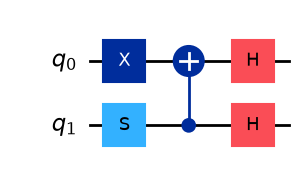
---

## Circuitos Complejos y Preparación de Protocolos

**6. Análisis de circuito desde diagrama II**
Observa detenidamente la siguiente imagen. Escribe el código en Qiskit para replicar el circuito mostrado (presta especial atención a qué qubit actúa como control y cuál como objetivo en las diferentes compuertas, y el orden de ejecución). Extrae el vector de estado final para responder cuál es la salida del circuito.

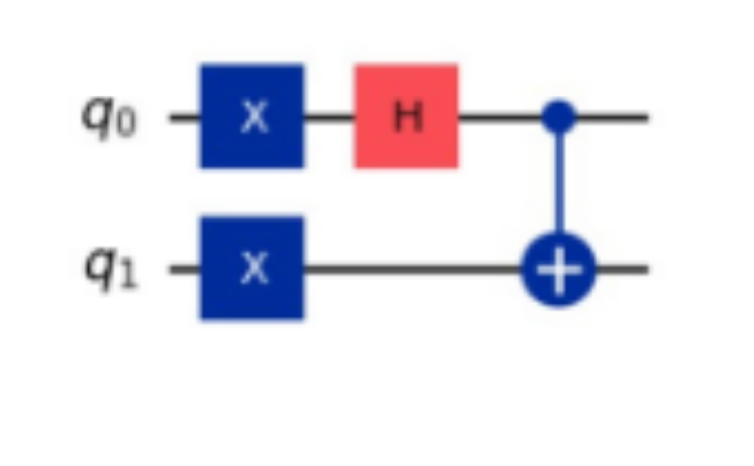


**7. Teleportación: Operaciones Locales de Alice**

En el protocolo de teleportación, Alice debe entrelazar localmente el qubit que desea enviar ($Q$) con su mitad del par de Bell ($A$). Escribe un fragmento de código creando un `QuantumCircuit` de 3 qubits (Q, A, B) y aplica las compuertas utilice la imagen como referencia 

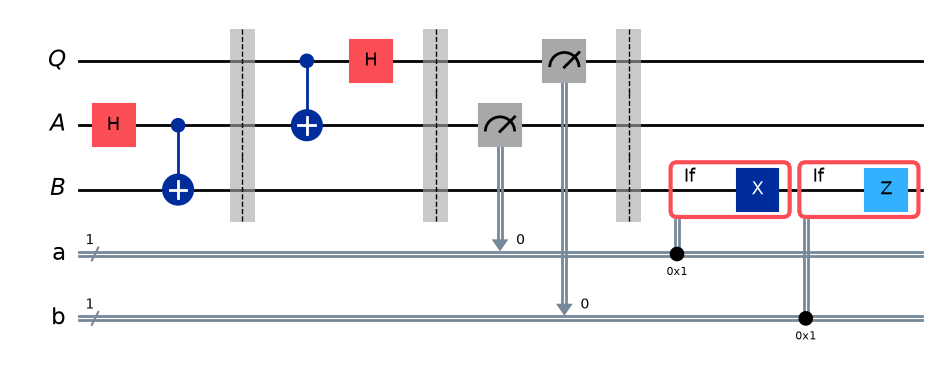



In [1]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install numpy
!pip install os
!pip install qiskit-ibm-runtime

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [2]:
"Qcircuito".draw('mpl') #dibujar el diagrama del circuito

estado = Statevector("Qcircuito")

#dVector de estado en notación Ket
diplay(estado.draw('latex')) 

# dibuja la Esferas de Bloch
plot_bloch_multivector(estado) 

#histograma de probabilidades del/los estados base
probabilidades = estado.probabilities_dict()
grafico_probs = plot_histogram(probabilidades, title="Probabilidades de los Estados Base")
display(grafico_probs)


AttributeError: 'str' object has no attribute 'draw'

# Dependecnias 

In [21]:
import os
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_bloch_multivector, array_to_latex, plot_histogram # ¡Agregamos plot_histogram!
from IPython.display import display, Markdown
from numpy import sqrt

zero = Statevector.from_label("0")
one = Statevector.from_label("1")
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")


# Hay más formas de escribir código con los mismos resultados, esta es una forma y la que se esperaba, debido a que es la más sencilla 

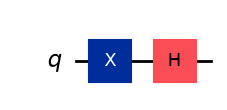

<IPython.core.display.Latex object>

In [5]:
# pregunta 1
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
vec = Statevector(qc)
display(qc.draw("mpl"))
display(vec.draw("latex"))

In [7]:
# pregunta 2
# habiendo inicializado los state vectors antes
phi = plus.tensor(one)
display(phi.draw('latex'))


<IPython.core.display.Latex object>

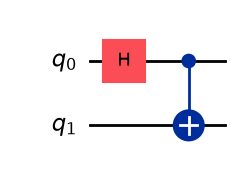

<IPython.core.display.Latex object>

In [9]:
## pregunta 3
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
vec = Statevector(qc)
display(qc.draw("mpl"))
display(vec.draw("latex"))



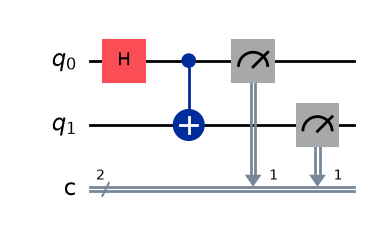

In [16]:
# pregunta 4
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure(0,1)
qc.measure(1,1)

display(qc.draw("mpl"))


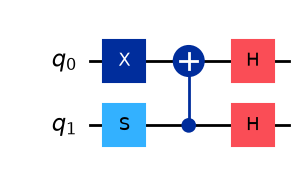

<IPython.core.display.Latex object>

In [17]:
# pregunta 5
qc = QuantumCircuit(2)
qc.x(0)
qc.s(1)
qc.cx(1,0)
qc.h(0)
qc.h(1)
vec = Statevector(qc)
display(qc.draw("mpl"))
display(vec.draw("latex"))

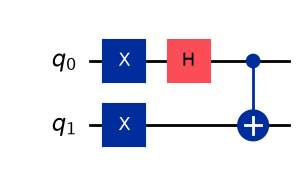

<IPython.core.display.Latex object>

In [18]:
# pregunta 6
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.h(0)
qc.cx(0,1)

vec = Statevector(qc)
display(qc.draw("mpl"))
display(vec.draw("latex"))


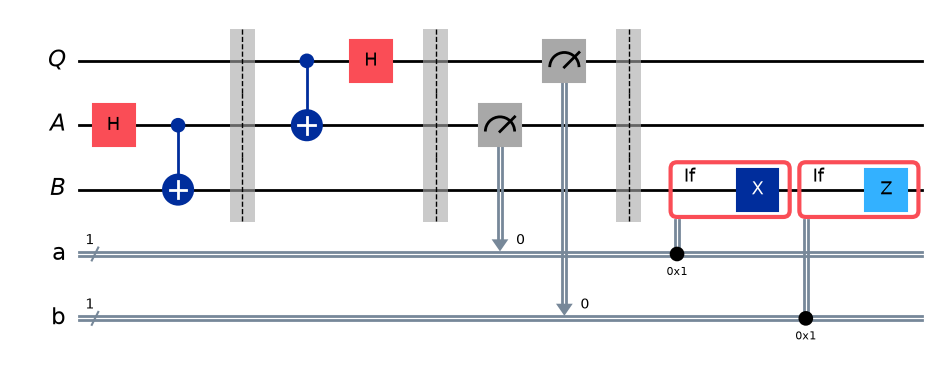

In [22]:
# Pregunta 7
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()
# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)
display(protocol.draw(output="mpl"))